In [1]:
#Import packages 

import numpy as np 
import pandas as pd 
import json 
import glob
import os
import csv
from statsmodels.tsa.seasonal import seasonal_decompose

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

In [2]:
from pathlib import Path

DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)


In [3]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Undervolt Threshold 

In [4]:
min_volt_thresh = 23 # there were values THIS low in the dataset 

In [5]:
# Frequency Threshold 
freq_thresh = 30

## Normal Undervoltage Threshold (10% below) 
under_volt_thresh = 230 - (0.1 * 230)

## Very low Undervoltage Threshold (20% below) 
very_low_undervolt_thresh = 230 - (0.2 * 230) 

## Normal Overvoltage Threshold (10% above) 
over_volt_thresh = 230 + (0.1 * 230)

## Very high overvoltage threshold (20% above)
very_high_overvolt_thresh = 230 + (0.2 * 230) 

#### SPECIFY DURATIONS 

# minimum outage duration 
min_outage_duration = 5

# undervolt, very_low_undervolt
min_undervolt_duration = 5

# overvolt, very_high_overvolt
min_overvolt_duration = 2


############## 


def filter_by_site(df, site_id):
    new_df = df[df['site_id'] == site_id]
    return new_df 


def clean_up_df(df):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values(by='time').reset_index(drop=True)

    # Select relevant columns
    df = df[['time', 'respondent_id', 'site_latitude', 'site_longitude', 
             'voltage', 'frequency', 'site_id', 'district', 'region', 'is_powered']]

    return df 


def read_and_concatenate_csvs(folder_path):
    # Find all CSV files in the folder
    csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    
    # Read and concatenate
    df_list = [pd.read_csv(file, low_memory=False) for file in csv_files]
    concatenated_df = pd.concat(df_list, ignore_index=True)
    
    print(f"Concatenated {len(csv_files)} files.")
    return concatenated_df


### version for samples 
def read_and_concatenate_csvs_sampled(
    folder_path,
    start_date=None,   # e.g. '2022-01-01'
    end_date=None      # e.g. '2022-03-31'
):
    # Convert to datetime if provided
    if start_date:
        start_date = pd.to_datetime(start_date)
    if end_date:
        end_date = pd.to_datetime(end_date)

    csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

    selected_files = []

    for file in csv_files:
        filename = os.path.basename(file).replace('.csv', '')
        
        try:
            file_date = pd.to_datetime(filename)
        except:
            continue  # skip files that don't match date format

        if start_date and file_date < start_date:
            continue
        if end_date and file_date > end_date:
            continue

        selected_files.append(file)

    df_list = [pd.read_csv(file, low_memory=False) for file in selected_files]
    
    if not df_list:
        print("No files found in specified date range.")
        return pd.DataFrame()

    concatenated_df = pd.concat(df_list, ignore_index=True)

    print(f"Concatenated {len(selected_files)} files.")
    return concatenated_df

## New Functions 

### Process the 2 minute sensor data 

In [6]:
### use this to run flags PER SITE 

def process_data_voltage_2min_version(df, 
                                      min_volt_thresh = min_volt_thresh, 
                                      under_volt_thresh = under_volt_thresh, 
                                      site_ids=None):
    
    df = df.copy()

    # Initialize an empty list to store results
    all_stats = []
    
    # If site_ids are provided, process for each site
    if site_ids is not None:
        for site_id in site_ids:

            #### Run the below per site_id #### 
            site_df = filter_by_site(df, site_id=site_id)
            
            # If no data for that site 
            if site_df.empty:
                # print(f"Site {site_id} not found or no data available. Skipping...")
                continue

            #### VOLTAGE SECTION #### 
            # Perform resampling to 2-min 
            # print(f"Resampling for site {site_id}...")
            df_voltage_2_min = analyze_sensor_voltage_flags(
                site_df, 
                min_volt_thresh, 
                under_volt_thresh 
            )
            
            #### APPEND TO LIST #### 
            all_stats.append(df_voltage_2_min)
    
    else:
        # If no specific sites are provided 
        print("No site list provided...")

    # Concatenate results if there are any
    if all_stats:
        print("Concatenating 2-min data for all sites")
        final_df = pd.concat(all_stats, ignore_index=True)
    else:
        final_df = pd.DataFrame()  # Return an empty DataFrame if no data is processed
    
    return final_df


############## 


## includes raw voltages + % voltage drops

def analyze_sensor_voltage_flags(
    df, 
    min_volt_thresh, 
    under_volt_thresh,
    nominal_voltage=230
):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)
    unique_sensors = df['respondent_id'].unique()

    result_df = (
        df[['time']]
        .drop_duplicates()
        .sort_values('time')
        .reset_index(drop=True)
    )

    for i, sensor in enumerate(unique_sensors, start=1):
        sensor_df = (
            df[df['respondent_id'] == sensor]
            .sort_values('time')
            .copy()
        )

        id_col   = f'sensor_{i}_id'
        flag_col = f'sensor_{i}_flag'
        pct_col  = f'sensor_{i}_percent_drop'
        volt_col = f'sensor_{i}_voltage'          # NEW

        sensor_df[id_col] = sensor

        is_undervolt = (
            (sensor_df['voltage'] > min_volt_thresh) &
            (sensor_df['voltage'] < under_volt_thresh) &
            (sensor_df['is_powered'])
        )

        sensor_df[flag_col] = is_undervolt.astype(int)

        percent_drop = ( ((nominal_voltage - sensor_df['voltage']) / nominal_voltage) * 100).round(2)
        sensor_df[pct_col]  = percent_drop.where(is_undervolt, 0)
        sensor_df[volt_col] = sensor_df['voltage'].round(2)   # NEW

        result_df = result_df.merge(
            sensor_df[['time', id_col, flag_col, pct_col, volt_col]],  # NEW
            on='time',
            how='left'
        )

    result_df['site_id'] = df['site_id'].iloc[0]

    sensor_cols = []
    for i in range(1, len(unique_sensors)+1):
        sensor_cols += [
            f'sensor_{i}_id',
            f'sensor_{i}_flag',
            f'sensor_{i}_voltage',        # NEW
            f'sensor_{i}_percent_drop',
        ]

    result_df = result_df[['time', 'site_id'] + sensor_cols]

    return result_df

### Clean up the 2-min df (such that the min duration and min recovery duration filtering are applied) 

In [7]:
### this is working fine now!! -> min undervoltage duration and recovery duration 

In [8]:
def clean_undervolt_duration_range_fixed_rev2(
    df,
    min_undervolt_duration=5,
    max_undervolt_duration=99999,
    min_recovery_duration=5
):
    df = df.copy()
    df = df.sort_values(['site_id', 'time']).reset_index(drop=True)

    flag_cols = [c for c in df.columns if c.endswith('_flag')]
    sensors = [c.replace('_flag', '') for c in flag_cols]

    for site_id, site_df in df.groupby('site_id'):
        site_idx = site_df.index
        site_df = site_df.sort_values('time')

        median_interval_min = (
            site_df['time'].diff().median().total_seconds() / 60
        )
        if pd.isna(median_interval_min):
            median_interval_min = 1

        for sensor in sensors:
            flag_col = f"{sensor}_flag"
            if flag_col not in site_df.columns:
                continue

            temp = site_df[['time', flag_col]].copy()
            temp['is_event'] = temp[flag_col] == 1

            # STEP 1: Identify groups
            temp['group'] = (temp['is_event'] != temp['is_event'].shift(1)).cumsum()

            group_info = temp.groupby('group').agg(
                start=('time', 'first'),
                end=('time', 'last'),
                is_event=('is_event', 'first')
            )

            group_info['duration_min'] = (
                (group_info['end'] - group_info['start']).dt.total_seconds() / 60
            ) + median_interval_min

            group_info['duration_min'] = group_info['duration_min'].clip(lower=median_interval_min)

            # ✅ STEP 1.5: Remove short events
            group_info['is_event'] = group_info.apply(
                lambda row: row['is_event'] and row['duration_min'] >= min_undervolt_duration,
                axis=1
            )

            # ✅ STEP 2: Chain extension through ALL short recoveries
            group_info = group_info.reset_index()

            i = 0
            while i < len(group_info) - 1:
                curr_row = group_info.loc[i]

                if curr_row['is_event'] and curr_row['duration_min'] >= min_undervolt_duration:
                    j = i + 1

                    # extend forward through consecutive short recoveries
                    while j < len(group_info):
                        next_row = group_info.loc[j]

                        if (
                            not next_row['is_event'] and
                            next_row['duration_min'] < min_recovery_duration
                        ):
                            group_info.loc[j, 'is_event'] = True
                            j += 1
                        else:
                            break

                    i = j
                else:
                    i += 1

            group_info = group_info.set_index('group')

            # STEP 3: Expand back to row-level
            merged_temp = temp[['time']].copy()
            group_map = group_info['is_event'].to_dict()
            merged_temp['is_event'] = temp['group'].map(group_map)

            # STEP 4: Recompute groups after extension
            merged_temp['group'] = (merged_temp['is_event'] != merged_temp['is_event'].shift(1)).cumsum()

            merged_group_info = merged_temp.groupby('group').agg(
                start=('time', 'first'),
                end=('time', 'last'),
                is_event=('is_event', 'first')
            )

            merged_group_info['duration_min'] = (
                (merged_group_info['end'] - merged_group_info['start']).dt.total_seconds() / 60
            ) + median_interval_min

            # STEP 5: Final duration filter
            merged_group_info['keep'] = merged_group_info.apply(
                lambda row: (
                    row['is_event'] and
                    min_undervolt_duration <= row['duration_min'] <= max_undervolt_duration
                ) or (not row['is_event']),
                axis=1
            )

            # STEP 6: Map back to rows
            final_keep_map = merged_group_info['keep'].to_dict()
            merged_temp['keep'] = merged_temp['group'].map(final_keep_map)

            # STEP 7: Final cleaned flag
            cleaned_flag = (merged_temp['is_event'] & merged_temp['keep']).astype(int)

            df.loc[site_idx, flag_col] = cleaned_flag.values

    return df

### Sensor - CESI Mapping 

### using `rev1` version --> (2 CESI clusters instead of 3)  

In [9]:
### CESI Mapping here 
sensor_cesi_mapping = pd.read_csv(DATA_DIR / 'miscellaneous/sensor_cesi_mapping_rev1.csv').drop(columns=['Unnamed: 0'])

## *** Reading processed hourly data 

### `2022` 

In [10]:
processed_hourly_voltage_df_22 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_22.csv')

### `2023` 

In [11]:
processed_hourly_voltage_df_23 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_23.csv')

### `concat` 

In [12]:
combined_hourly_voltage_df = pd.concat(
    [
        processed_hourly_voltage_df_22,
        processed_hourly_voltage_df_23
    ],
    ignore_index=True
)

### keep only sensors of interest 

In [13]:
sensor_of_interest_list = pd.read_csv(DATA_DIR / 'miscellaneous/common_sensors_22_23_rev4.csv')['respondent_id'].unique().tolist()

combined_hourly_voltage_df = combined_hourly_voltage_df[combined_hourly_voltage_df['sensor_id'].isin(sensor_of_interest_list)].reset_index(drop=True)

In [14]:
combined_hourly_voltage_df = combined_hourly_voltage_df.merge(sensor_cesi_mapping, on = 'sensor_id')

In [15]:
combined_hourly_voltage_df

,time,site_id,sensor_id,voltage,valid_fraction,n_available_timestamps,n_valid_timestamps,expected_timestamps,cesi_level
0,2022-01-01 00:00:00,1,bb3ff846,236.64,1.000,30,30,30,Low
1,2022-01-01 01:00:00,1,bb3ff846,235.38,1.000,30,30,30,Low
2,2022-01-01 02:00:00,1,bb3ff846,235.45,0.967,29,29,30,Low
3,2022-01-01 03:00:00,1,bb3ff846,236.54,1.000,30,30,30,Low
4,2022-01-01 04:00:00,1,bb3ff846,237.72,1.000,30,30,30,Low
...,...,...,...,...,...,...,...,...,...
7098872,2023-12-31 09:00:00,473,3a67dee6,NaN,0.000,30,0,30,High
7098873,2023-12-31 10:00:00,473,3a67dee6,NaN,0.000,29,0,30,High
7098874,2023-12-31 11:00:00,473,3a67dee6,NaN,0.000,29,0,30,High
7098875,2023-12-31 12:00:00,473,3a67dee6,NaN,0.000,30,0,30,High


### Summary Stats -> Hourly Voltages 

In [16]:
percentiles_df = (
    combined_hourly_voltage_df['voltage']
    .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

percentiles_df.columns = ['percentile', 'voltage']
percentiles_df['percentile'] = (
    percentiles_df['percentile'] * 100
).astype(int)

In [17]:
percentiles_df

,percentile,voltage
0,1,183.14
1,5,204.31
2,10,212.90
3,25,224.16
4,50,234.09
5,75,241.94
6,90,248.47
7,95,252.19
8,99,258.46


In [18]:
combined_hourly_voltage_df['voltage'].quantile(0.062)

np.float64(207.02)

### low voltage threshold: 207V (undervolt threshold): 6.2 percentile 

In [19]:
# OR 

# propose low voltage threshold - 5th percentile seems reasonable -> for temp I am looking at the 95th percentile 

In [20]:
# (why am I now seeing very few undervoltages?) -- possibly cos of the 'within hour definition'? 

# previously, it was spanning multiple...but still... 

# the logit I run was for 207V anyways and the results were not gidigidi -> so should be worse if I reduce it 

### Low & High CESI 

In [21]:
low_cesi_df = combined_hourly_voltage_df[combined_hourly_voltage_df['cesi_level'] == 'Low'].reset_index(drop=True)

high_cesi_df = combined_hourly_voltage_df[combined_hourly_voltage_df['cesi_level'] == 'High'].reset_index(drop=True)

## *** Plots 

### Plot hourly voltages (all) 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voltage_timeseries_envelope(
    df,
    start_time=None,
    end_time=None,
    site_ids=None,
    cesi_level=None,          # 'Low', 'Medium', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(15, 5),
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Time',
    legend_loc='best',
    legend_bbox=None,
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5, 
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if start_time is not None:
        plot_df = plot_df[plot_df['time'] >= pd.to_datetime(start_time)]

    if end_time is not None:
        plot_df = plot_df[plot_df['time'] <= pd.to_datetime(end_time)]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    cesi_colors = {
        'Low': {
            'line': '#6a51a3',
            'band': '#bcbddc'
        },
        'Medium': {
            'line': '#238b45',
            'band': '#a1d99b'
        },
        'High': {
            'line': '#8c2d04',
            'band': '#fdbb84'
        }
    }

    if line_color is None:
        line_color = cesi_colors.get(
            cesi_level, {}
        ).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(
            cesi_level, {}
        ).get('band', 'gray')

    grouped = (
        plot_df
        .groupby('time')['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
    )

    plt.figure(figsize=figsize)
    ax = plt.gca()

    ax.fill_between(
        grouped['time'],
        grouped['lower'],
        grouped['upper'],
        color=band_color,
        alpha=alpha_band,
        label=f'{int(lower_q*100)}th–{int(upper_q*100)}th percentile'
    )

    label_prefix = f'{cesi_level} CESI ' if cesi_level is not None else ''

    ax.plot(
        grouped['time'],
        grouped['center_value'],
        color=line_color,
        linewidth=linewidth,
        label=f'{label_prefix}{center.capitalize()}'
    )

    if show_voltage_bounds:

        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Lower Bound ({lower_bound:.0f} V)'
        )

        ax.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Upper Bound ({upper_bound:.0f} V)'
        )

    ax.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    title_parts = []

    if cesi_level is not None:
        title_parts.append(f'{cesi_level} CESI')

    if site_ids is not None:
        title_parts.append(f'{len(site_ids)} selected site(s)')

    if len(title_parts) > 0:
        ax.set_title(
            ' | '.join(title_parts),
            fontsize=14,
            fontweight='bold'
        )
        
    # -------------------------
    # Optional y limits
    # -------------------------
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

    return grouped

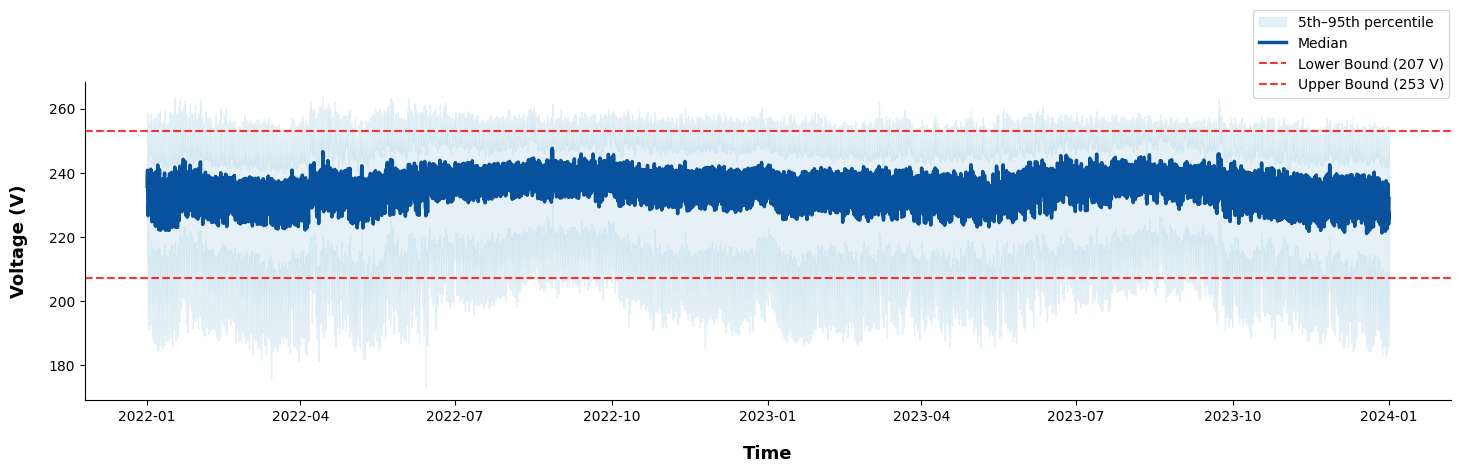

In [23]:
summary_all = plot_voltage_timeseries_envelope(
    combined_hourly_voltage_df,
    cesi_level=None, 
    # start_time='2022-01-15',
    # end_time='2022-02-15',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    show_voltage_bounds=True,
    line_color='#08519c',
    band_color='#9ecae1',
    legend_loc='upper left',
    legend_bbox=(0.85, 1.25)
)

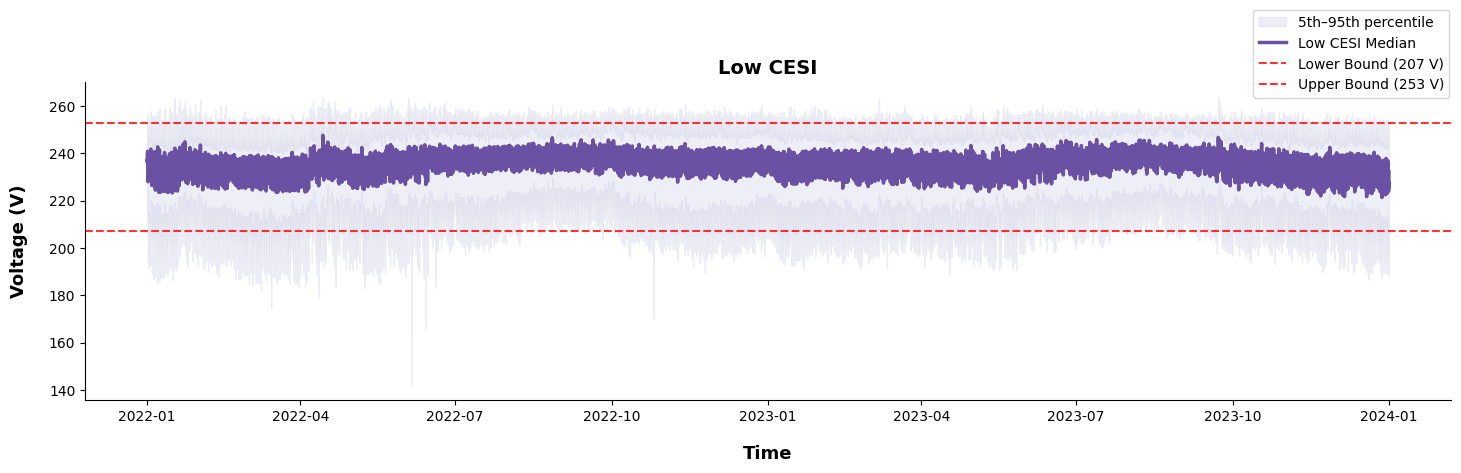

In [24]:
summary_low = plot_voltage_timeseries_envelope(
    combined_hourly_voltage_df,
    cesi_level='Low',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    show_voltage_bounds=True,
    legend_loc='upper left',
    legend_bbox=(0.85, 1.25), 
    # ylim=(200, 260)
)

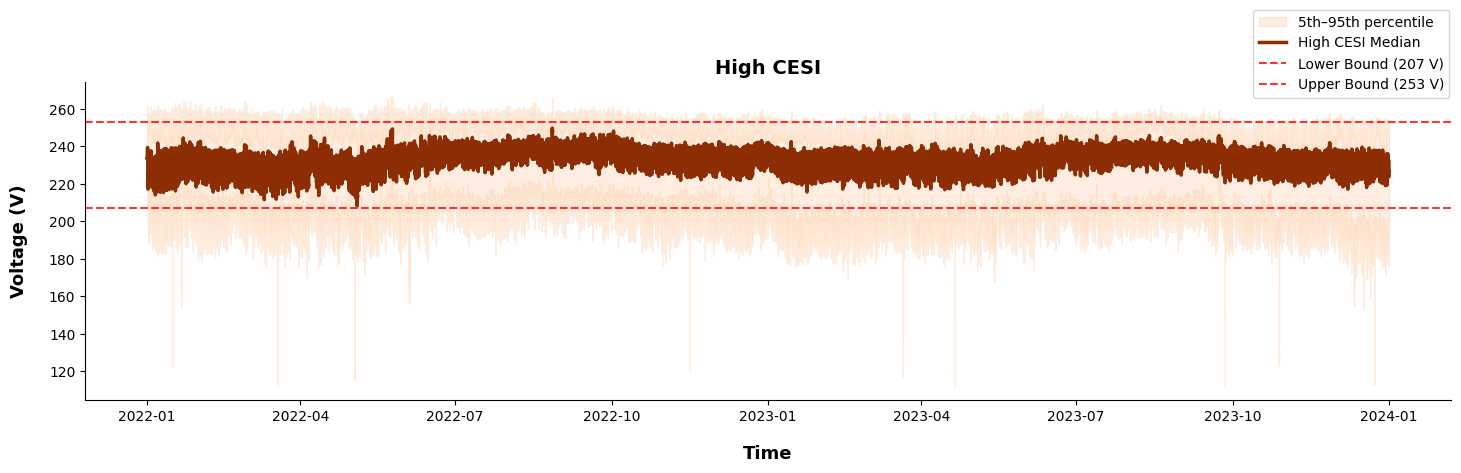

In [25]:
summary_high = plot_voltage_timeseries_envelope(
    combined_hourly_voltage_df,
    cesi_level='High',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    show_voltage_bounds=True,
    legend_loc='upper left',
    legend_bbox=(0.85, 1.25), 
    # ylim=(200, 260)
)

### Histogram 

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

def plot_voltage_histogram(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    bins=40,
    ignore_zero=True,
    normalize=True,
    figsize=(10, 6),
    color=None,
    alpha=0.7,
    show_kde=True,
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    xlabel='Hourly Voltage (V)',
    ylabel=None,
    legend_loc='best',
    legend_bbox=None
):

    plot_df = df.copy()

    # -------------------------
    # Optional site filtering
    # -------------------------
    if site_ids is not None:
        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    # -------------------------
    # Optional CESI filtering
    # -------------------------
    if cesi_level is not None:
        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    # -------------------------
    # Remove zero voltages
    # -------------------------
    if ignore_zero:
        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(subset=['voltage'])

    # -------------------------
    # Auto colors
    # -------------------------
    cesi_colors = {
        'Low': '#6a51a3',
        'Medium': '#238b45',
        'High': '#8c2d04'
    }

    if color is None:
        color = cesi_colors.get(
            cesi_level,
            '#3182bd'
        )

    # -------------------------
    # Histogram stat
    # -------------------------
    stat = 'percent' if normalize else 'count'

    if ylabel is None:
        ylabel = (
            'Percentage of Observations'
            if normalize
            else 'Count'
        )

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=figsize)

    ax = sns.histplot(
        data=plot_df,
        x='voltage',
        bins=bins,
        kde=show_kde,
        stat=stat,
        color=color,
        alpha=alpha
    )

    # -------------------------
    # Voltage bounds
    # -------------------------
    if show_voltage_bounds:

        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax.axvline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            label=f'Lower Bound ({lower_bound:.0f} V)'
        )

        ax.axvline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            label=f'Upper Bound ({upper_bound:.0f} V)'
        )

    # -------------------------
    # Title
    # -------------------------
    if cesi_level is not None:
        ax.set_title(
            f'',
            fontsize=14,
            fontweight='bold'
        )

    # -------------------------
    # Labels
    # -------------------------
    ax.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    if normalize:
        ax.yaxis.set_major_formatter(
            PercentFormatter()
        )

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

    return plot_df

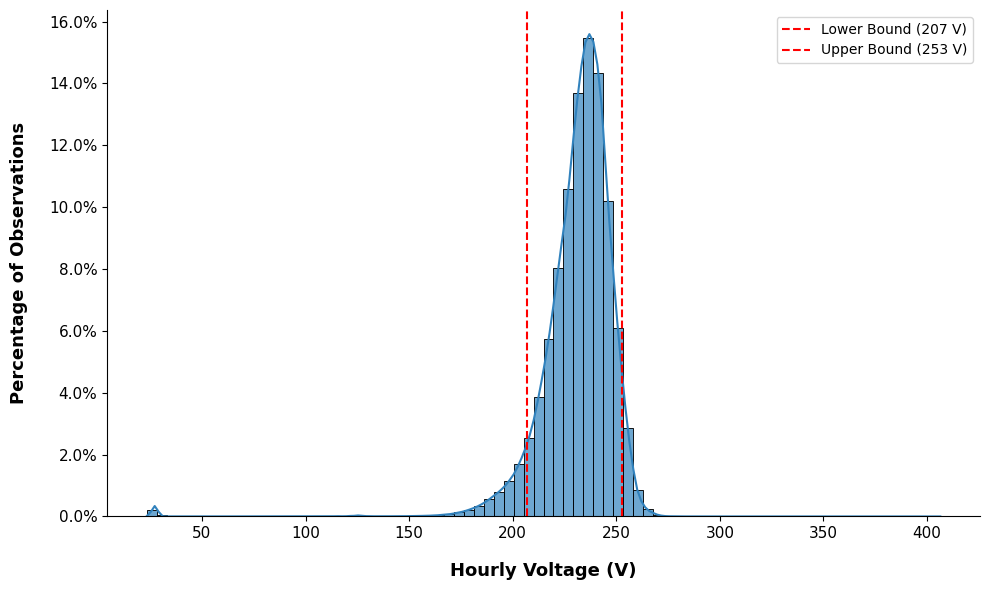

In [27]:
all_volt_histogram = plot_voltage_histogram(
    combined_hourly_voltage_df,
    cesi_level = None,
    bins = 80
)

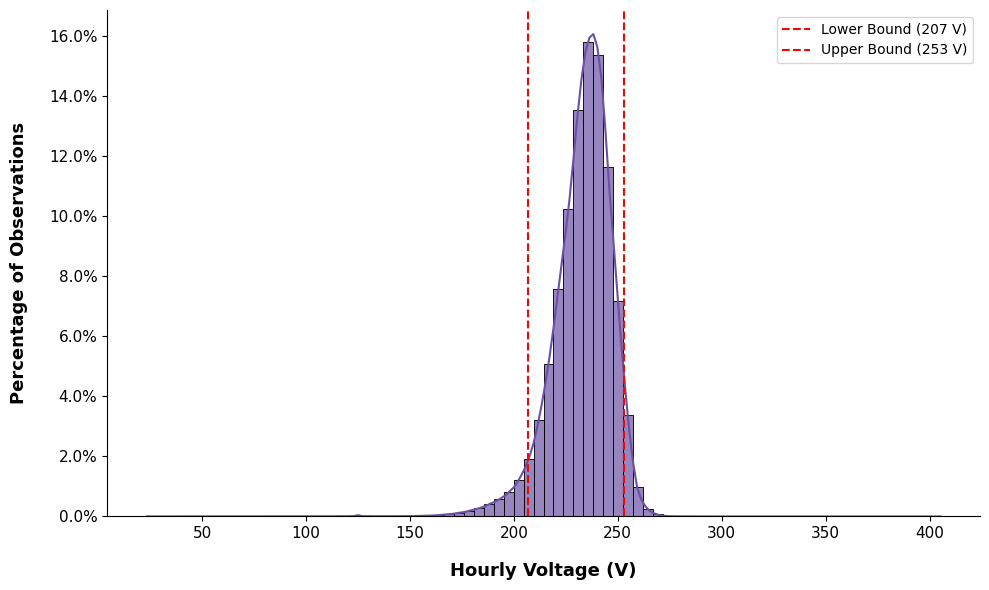

In [28]:
low_cesi_volt_histogram = plot_voltage_histogram(
    combined_hourly_voltage_df,
    cesi_level='Low',
    bins=80
)

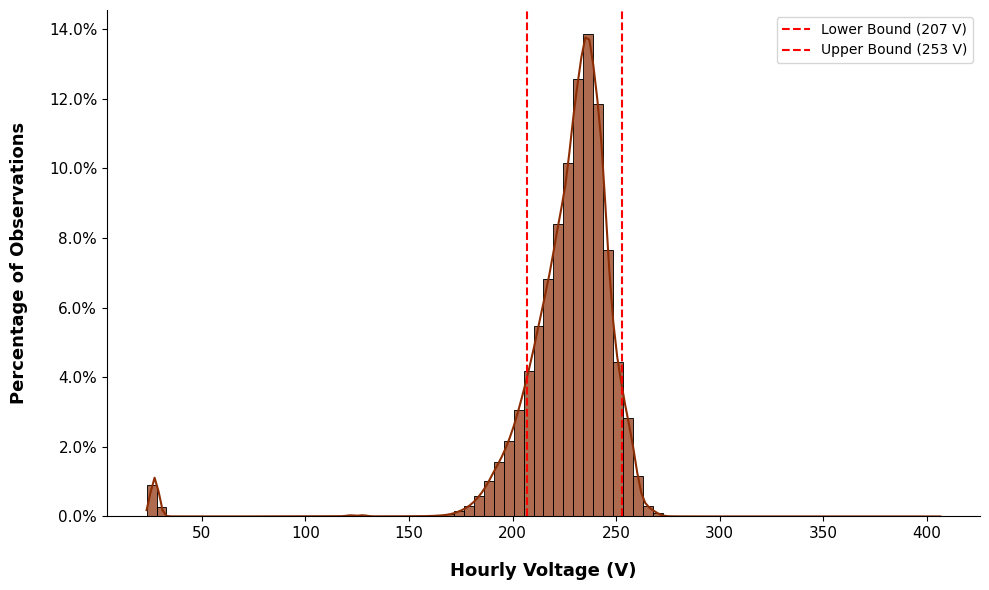

In [29]:
high_cesi_volt_histogram = plot_voltage_histogram(
    combined_hourly_voltage_df,
    cesi_level='High',
    bins=80
)

## *** Hour of the day 

### Hourly summary (individual sensors) 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voltage_by_hour_of_day(
    df,
    site_ids=None,
    figsize=(12, 6),
    show_sensor_lines=True,
    show_site_average=False,
    estimator='mean',
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    legend_loc='best'
):

    plot_df = df.copy()

    # -------------------------
    # Datetime handling
    # -------------------------
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    # Filter sites if provided
    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    # -------------------------
    # Hour of day
    # -------------------------
    plot_df['hour'] = plot_df['time'].dt.hour

    # -------------------------
    # Aggregation function
    # -------------------------
    if estimator == 'mean':
        agg_func = 'mean'
    elif estimator == 'median':
        agg_func = 'median'
    else:
        raise ValueError("estimator must be 'mean' or 'median'")

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # -------------------------
    # Plot individual sensors
    # -------------------------
    if show_sensor_lines:

        sensor_grouped = (
            plot_df
            .groupby(['sensor_id', 'hour'])['voltage']
            .agg(agg_func)
            .reset_index()
            .sort_values('hour')
        )

        sns.lineplot(
            data=sensor_grouped,
            x='hour',
            y='voltage',
            hue='sensor_id',
            marker='o',
            linewidth=2,
            alpha=0.7,
            ax=ax
        )

    # -------------------------
    # Plot overall site average
    # -------------------------
    if show_site_average:

        site_grouped = (
            plot_df
            .groupby('hour')['voltage']
            .agg(agg_func)
            .reset_index()
            .sort_values('hour')
        )

        ax.plot(
            site_grouped['hour'],
            site_grouped['voltage'],
            color='black',
            linestyle='--',
            linewidth=3,
            marker='o',
            label='Overall Average'
        )

    # -------------------------
    # Styling
    # -------------------------
    ax.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=12
    )

    ax.set_xticks(range(24))

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.legend(loc=legend_loc)

    sns.despine()

    plt.tight_layout()
    plt.show()

In [31]:
# plot_voltage_by_hour_of_day(
#     combined_hourly_voltage_df
# )

### Hourly summary (w/ percentiles) - `All Hours` 

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voltage_by_hour_of_day(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(12, 6),
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    legend_loc='best',
    legend_bbox=None,
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    # -------------------------
    # Filter sites
    # -------------------------
    if site_ids is not None:
        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    # -------------------------
    # Filter CESI level
    # -------------------------
    if cesi_level is not None:
        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    # -------------------------
    # Remove zero voltages
    # -------------------------
    if ignore_zero:
        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(
        subset=['time', 'voltage']
    )

    # -------------------------
    # Auto colors by CESI
    # -------------------------
    cesi_colors = {
        'Low': {
            'line': '#6a51a3',
            'band': '#bcbddc'
        },
        'Medium': {
            'line': '#238b45',
            'band': '#a1d99b'
        },
        'High': {
            'line': '#8c2d04',
            'band': '#fdbb84'
        }
    }

    if line_color is None:
        line_color = cesi_colors.get(
            cesi_level, {}
        ).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(
            cesi_level, {}
        ).get('band', 'gray')

    # -------------------------
    # Hour of day
    # -------------------------
    plot_df['hour'] = plot_df['time'].dt.hour

    # -------------------------
    # Validate center argument
    # -------------------------
    if center not in ['mean', 'median']:
        raise ValueError(
            "center must be either 'mean' or 'median'"
        )

    # -------------------------
    # Aggregate across sensors
    # -------------------------
    grouped = (
        plot_df
        .groupby('hour')['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values('hour')
    )

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    label_prefix = (
        f'{cesi_level} CESI '
        if cesi_level is not None
        else ''
    )

    ax.fill_between(
        grouped['hour'],
        grouped['lower'],
        grouped['upper'],
        color=band_color,
        alpha=alpha_band,
        label=f'{int(lower_q*100)}th–{int(upper_q*100)}th percentile'
    )

    ax.plot(
        grouped['hour'],
        grouped['center_value'],
        color=line_color,
        linewidth=linewidth,
        marker='o',
        label=f'{label_prefix}{center.capitalize()}'
    )

    # -------------------------
    # Voltage bounds
    # -------------------------
    if show_voltage_bounds:

        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Lower Bound ({lower_bound:.0f} V)'
        )

        ax.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Upper Bound ({upper_bound:.0f} V)'
        )

    # -------------------------
    # Optional title
    # -------------------------
    if cesi_level is not None:
        ax.set_title(
            f'{cesi_level} CESI',
            fontsize=14,
            fontweight='bold'
        )

    # -------------------------
    # Labels
    # -------------------------
    ax.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax.set_xticks(range(24))

    ax.tick_params(axis='x', labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # -------------------------
    # Optional y limits
    # -------------------------
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    sns.despine()
    plt.tight_layout()
    plt.show()

    return grouped

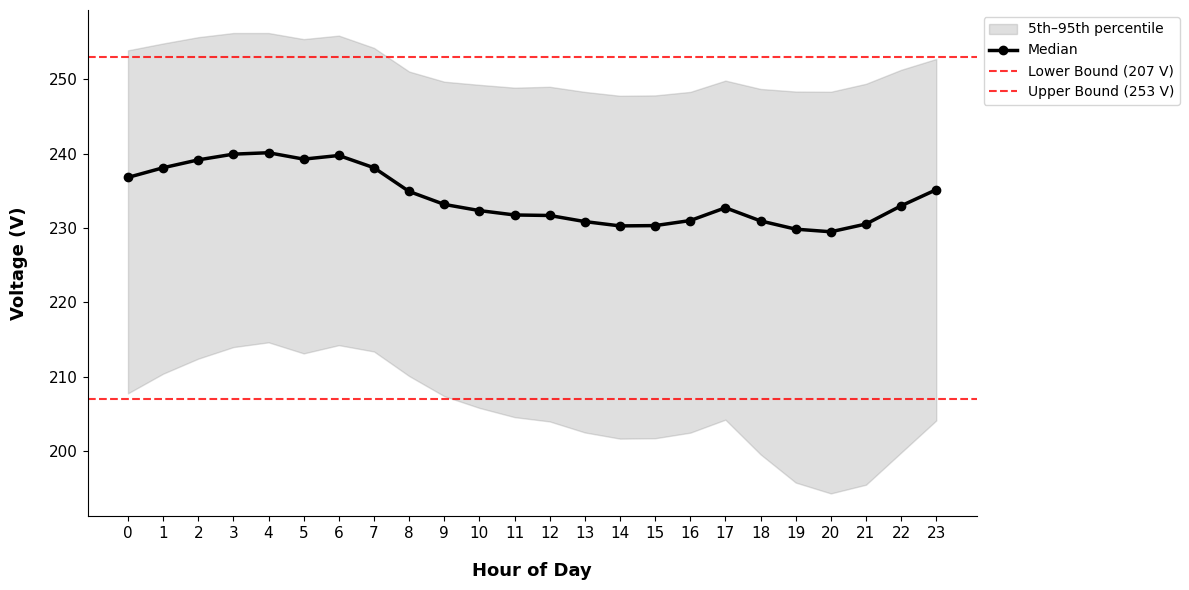

In [33]:
summary_all_hour = plot_voltage_by_hour_of_day(
    combined_hourly_voltage_df,
    cesi_level = None,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260), 
    legend_loc='upper left',
    legend_bbox=(1, 1)
)

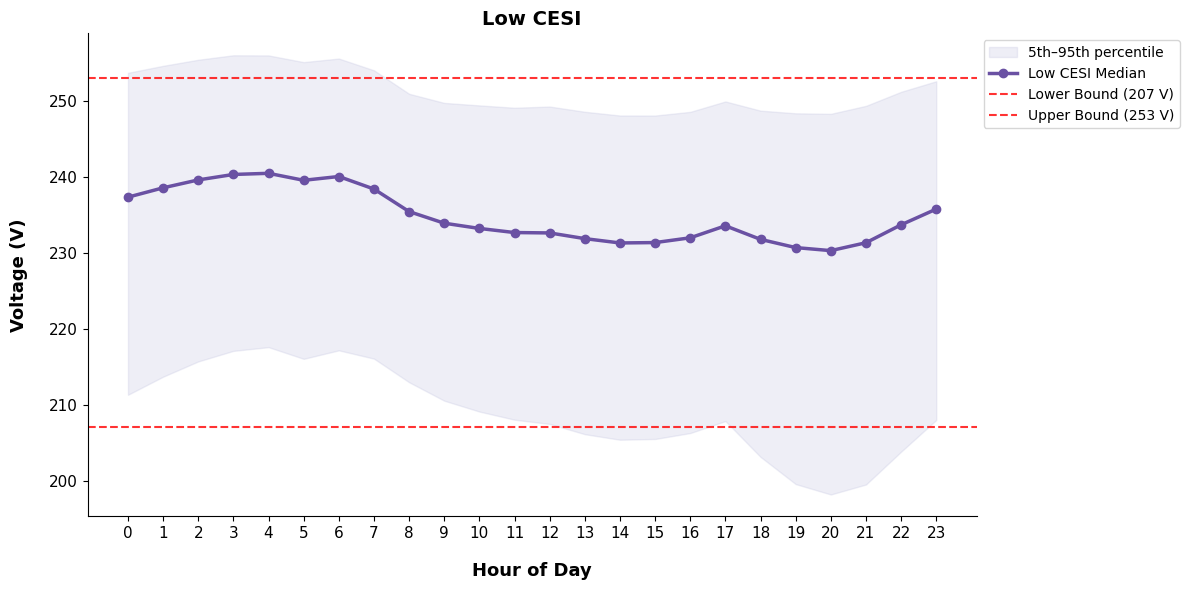

In [34]:
summary_low_cesi_hour = plot_voltage_by_hour_of_day(
    combined_hourly_voltage_df,
    cesi_level='Low',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260), 
    legend_loc='upper left',
    legend_bbox=(1, 1)
)

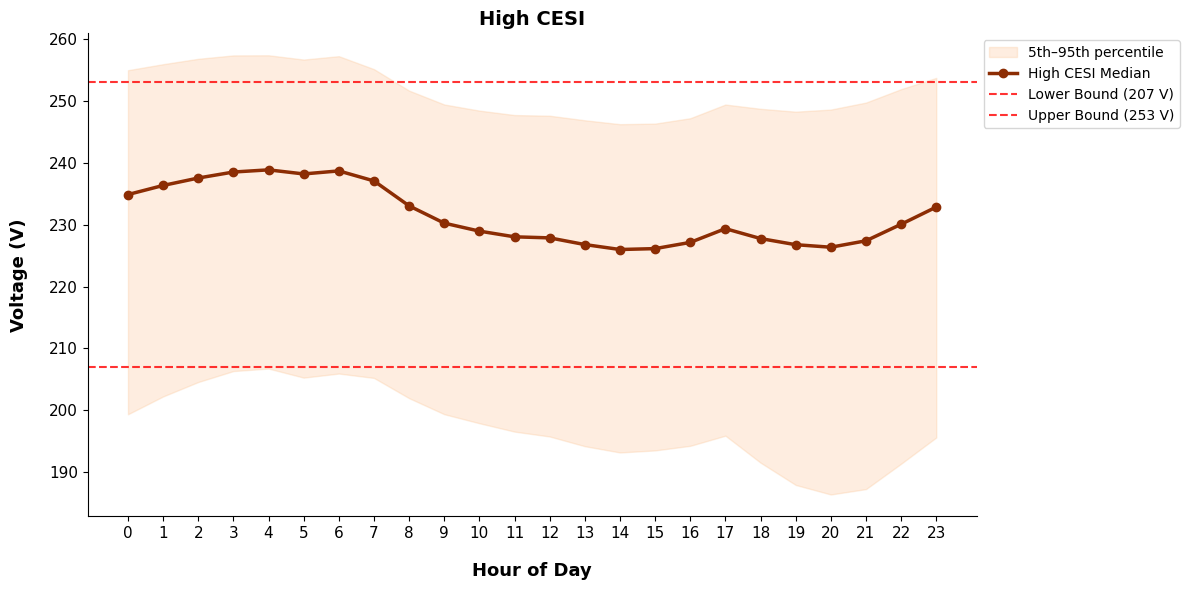

In [35]:
summary_high_cesi_hour = plot_voltage_by_hour_of_day(
    combined_hourly_voltage_df,
    cesi_level='High',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260), 
    legend_loc='upper left',
    legend_bbox=(1, 1)
)

### Hour of day plots (`by CESI`)  

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voltage_by_hour_of_day_by_cesi(
    df,
    site_ids=None,
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    cesi_order=None,
    cesi_colors=None,
    figsize=(14, 5),
    ncols=None,
    linewidth=2.5,
    alpha_band=0.25,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    sharey=True
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['voltage', 'cesi_level'])

    plot_df['hour'] = plot_df['time'].dt.hour

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    if cesi_order is None:
        cesi_order = sorted(plot_df['cesi_level'].unique())

    plot_df['cesi_level'] = pd.Categorical(
        plot_df['cesi_level'],
        categories=cesi_order,
        ordered=True
    )

    grouped = (
        plot_df
        .groupby(['cesi_level', 'hour'], observed=True)['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count',
            n_sensors=lambda x: plot_df.loc[x.index, 'sensor_id'].nunique()
        )
        .reset_index()
        .sort_values(['cesi_level', 'hour'])
    )

    if ncols is None:
        ncols = len(cesi_order)

    nrows = int(np.ceil(len(cesi_order) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).reshape(-1)

    if cesi_colors is None:
        cesi_colors = {
            'Low': '#6a51a3',
            'Medium': '#4393c3',
            'High': '#8c2d04'
        }

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, cesi in enumerate(cesi_order):

        ax = axes[i]

        sub = grouped[grouped['cesi_level'] == cesi]

        color = cesi_colors.get(cesi, 'black')

        ax.fill_between(
            sub['hour'],
            sub['lower'],
            sub['upper'],
            color=color,
            alpha=alpha_band,
            label=f'{int(lower_q*100)}th–{int(upper_q*100)}th percentile'
        )

        ax.plot(
            sub['hour'],
            sub['center_value'],
            color=color,
            linewidth=linewidth,
            marker='o',
            label=center.capitalize()
        )

        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8,
                label=f'Lower Bound ({lower_bound:.0f} V)'
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8,
                label=f'Upper Bound ({upper_bound:.0f} V)'
            )

        if len(sub) > 0:
            n_obs = int(sub['n'].sum())
            n_sensors = int(sub['n_sensors'].max())
            title = f'{cesi} CESI\nn sensors = {n_sensors:,}'
        else:
            title = f'{cesi} CESI\nn sensors = 0'

        ax.set_title(
            title,
            fontsize=13,
            fontweight='bold'
        )

        ax.set_xticks(range(24))

        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.10),
        ncol=4,
        frameon=False
    )

    plt.tight_layout()
    plt.show()

    return grouped

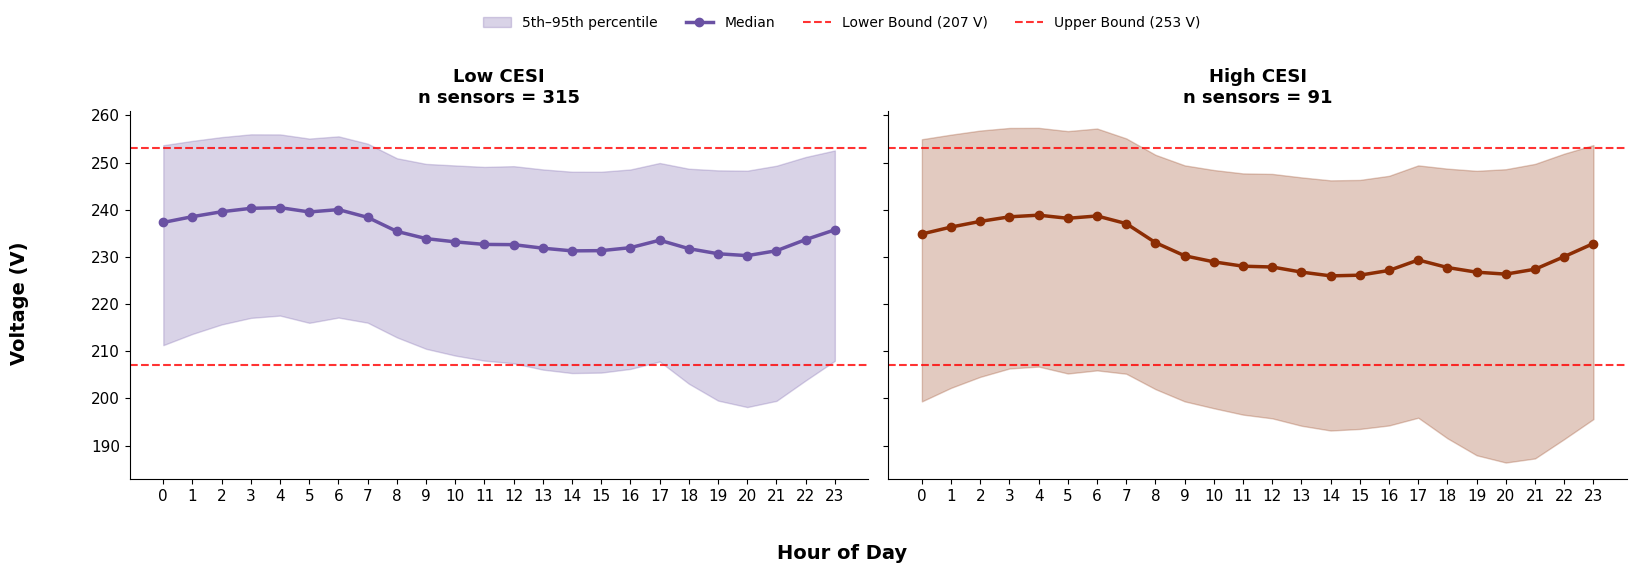

In [37]:
cesi_hourly_summary = plot_voltage_by_hour_of_day_by_cesi(
    combined_hourly_voltage_df,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    cesi_order=['Low', 'High'],
    figsize=(16, 5)
)

In [38]:
def plot_voltage_by_hour_of_day_by_cesi(
    df,
    site_ids=None,
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    cesi_order=None,
    cesi_colors=None,
    figsize=(14, 5),
    ncols=None,
    linewidth=2.5,
    alpha_band=0.25,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    sharey=True,
    xtick_hours=None,       # e.g. [0, 6, 12, 18, 23] to show only those hours
    save_path=None,
    dpi=300
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['voltage', 'cesi_level'])
    plot_df['hour'] = plot_df['time'].dt.hour

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    if cesi_order is None:
        cesi_order = sorted(plot_df['cesi_level'].unique())

    plot_df['cesi_level'] = pd.Categorical(
        plot_df['cesi_level'],
        categories=cesi_order,
        ordered=True
    )

    grouped = (
        plot_df
        .groupby(['cesi_level', 'hour'], observed=True)['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count',
            n_sensors=lambda x: plot_df.loc[x.index, 'sensor_id'].nunique()
        )
        .reset_index()
        .sort_values(['cesi_level', 'hour'])
    )

    if ncols is None:
        ncols = len(cesi_order)

    nrows = int(np.ceil(len(cesi_order) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).reshape(-1)

    if cesi_colors is None:
        cesi_colors = {
            'Low': '#6a51a3',
            'Medium': '#4393c3',
            'High': '#8c2d04'
        }

    lower_bound = nominal_voltage * (1 - tolerance)

    # Default: show all hours
    all_hours = list(range(24))
    if xtick_hours is None:
        xtick_hours = all_hours

    for i, cesi in enumerate(cesi_order):

        ax = axes[i]
        sub = grouped[grouped['cesi_level'] == cesi]
        color = cesi_colors.get(cesi, 'black')

        ax.fill_between(
            sub['hour'],
            sub['lower'],
            sub['upper'],
            color=color,
            alpha=alpha_band,
            label=f'{int(lower_q*100)}th–{int(upper_q*100)}th percentile'
        )

        ax.plot(
            sub['hour'],
            sub['center_value'],
            color=color,
            linewidth=linewidth,
            marker='o',
            label=center.capitalize()
        )

        if show_voltage_bounds:
            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8,
                label=f'Low Voltage Threshold ({lower_bound:.0f} V)'
            )

        if len(sub) > 0:
            n_sensors = int(sub['n_sensors'].max())
            title = f''
            # title = f'{cesi} CESI\nn sensors = {n_sensors:,}'

        else:
            # title = f'{cesi} CESI\nn sensors = 0'
            title = f''

        ax.set_title(title, fontsize=13, fontweight='bold')

        # Apply custom x ticks
        ax.set_xticks(xtick_hours)
        ax.set_xticklabels(xtick_hours)

        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.10),
        ncol=4,
        frameon=False
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()
    return grouped

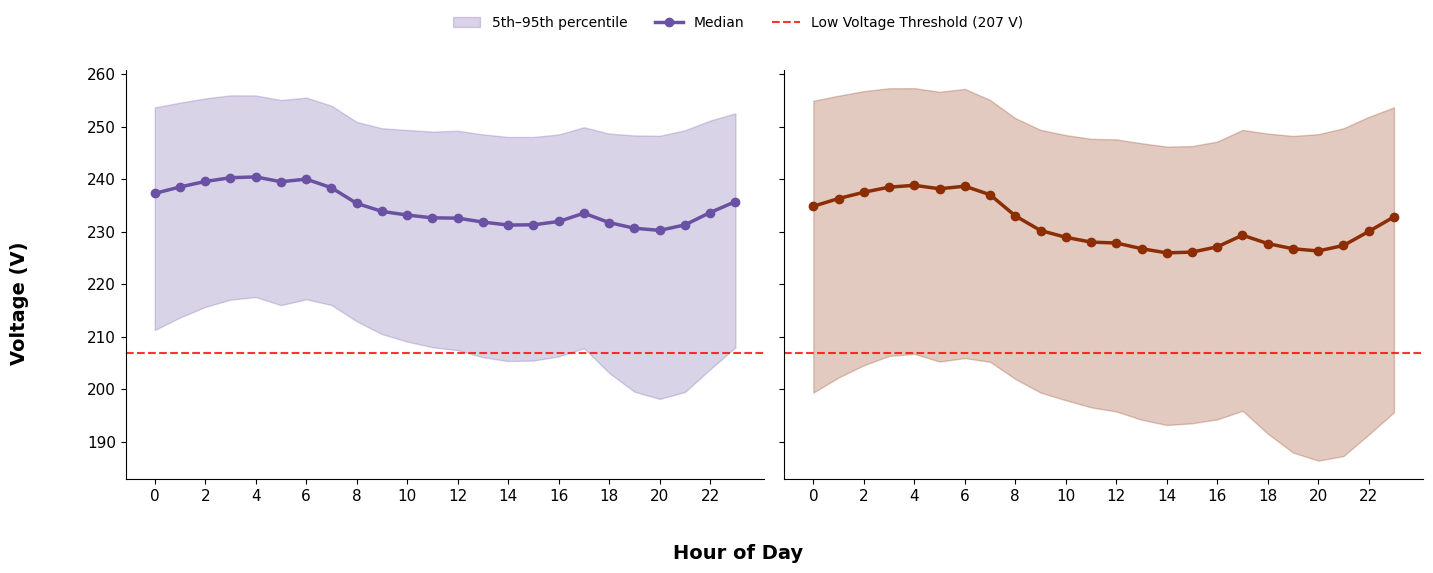

In [39]:
cesi_hourly_summary = plot_voltage_by_hour_of_day_by_cesi(
    combined_hourly_voltage_df,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    cesi_order=['Low', 'High'],
    figsize=(14, 5), 
    xtick_hours=[0,2,4,6,8,10,12,14,16,18,20,22],       
    save_path='hour_of_day_by_cesi.png'
)

In [40]:
def plot_voltage_by_hour_of_day_by_cesi(
    df,
    site_ids=None,
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    cesi_order=None,
    cesi_colors=None,
    figsize=(14, 5),
    ncols=None,
    linewidth=2.5,
    alpha_band=0.25,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    sharey=True,
    xtick_hours=None,
    legend_fontsize=13,
    save_path=None,
    dpi=300
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    import seaborn as sns

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['voltage', 'cesi_level'])
    plot_df['hour'] = plot_df['time'].dt.hour

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    if cesi_order is None:
        cesi_order = sorted(plot_df['cesi_level'].unique())

    plot_df['cesi_level'] = pd.Categorical(
        plot_df['cesi_level'],
        categories=cesi_order,
        ordered=True
    )

    grouped = (
        plot_df
        .groupby(['cesi_level', 'hour'], observed=True)['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count',
            n_sensors=lambda x: plot_df.loc[x.index, 'sensor_id'].nunique()
        )
        .reset_index()
        .sort_values(['cesi_level', 'hour'])
    )

    if ncols is None:
        ncols = len(cesi_order)

    nrows = int(np.ceil(len(cesi_order) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).reshape(-1)

    if cesi_colors is None:
        cesi_colors = {
            'Low': '#6a51a3',
            'Medium': '#4393c3',
            'High': '#8c2d04'
        }

    lower_bound = nominal_voltage * (1 - tolerance)

    if xtick_hours is None:
        xtick_hours = list(range(24))

    panel_labels = list('abcdefghij')

    for i, cesi in enumerate(cesi_order):

        ax = axes[i]
        sub = grouped[grouped['cesi_level'] == cesi]
        color = cesi_colors.get(cesi, 'black')

        # No labels on any plot elements — legend built manually
        ax.fill_between(
            sub['hour'],
            sub['lower'],
            sub['upper'],
            color=color,
            alpha=alpha_band
        )

        ax.plot(
            sub['hour'],
            sub['center_value'],
            color=color,
            linewidth=linewidth,
            marker='o'
        )

        if show_voltage_bounds:
            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        # Panel label
        ax.text(
            -0.07, 1.05, panel_labels[i],
            transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='bottom'
        )

        ax.set_xticks(xtick_hours)
        ax.set_xticklabels(xtick_hours)
        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    # -------------------------
    # Manual gray shared legend
    # -------------------------
    legend_handles = [
        mpatches.Patch(
            color='gray',
            alpha=0.4,
            label=f'{int(lower_q*100)}th–{int(upper_q*100)}th percentile'
        ),
        mlines.Line2D(
            [], [],
            color='gray',
            marker='o',
            linewidth=linewidth,
            label=center.capitalize()
        ),
    ]

    if show_voltage_bounds:
        legend_handles.append(
            mlines.Line2D(
                [], [],
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                label=f'Low Voltage Threshold ({lower_bound:.0f} V)'
            )
        )

    fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.10),
        ncol=len(legend_handles),
        frameon=False,
        fontsize=legend_fontsize
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()
    return grouped

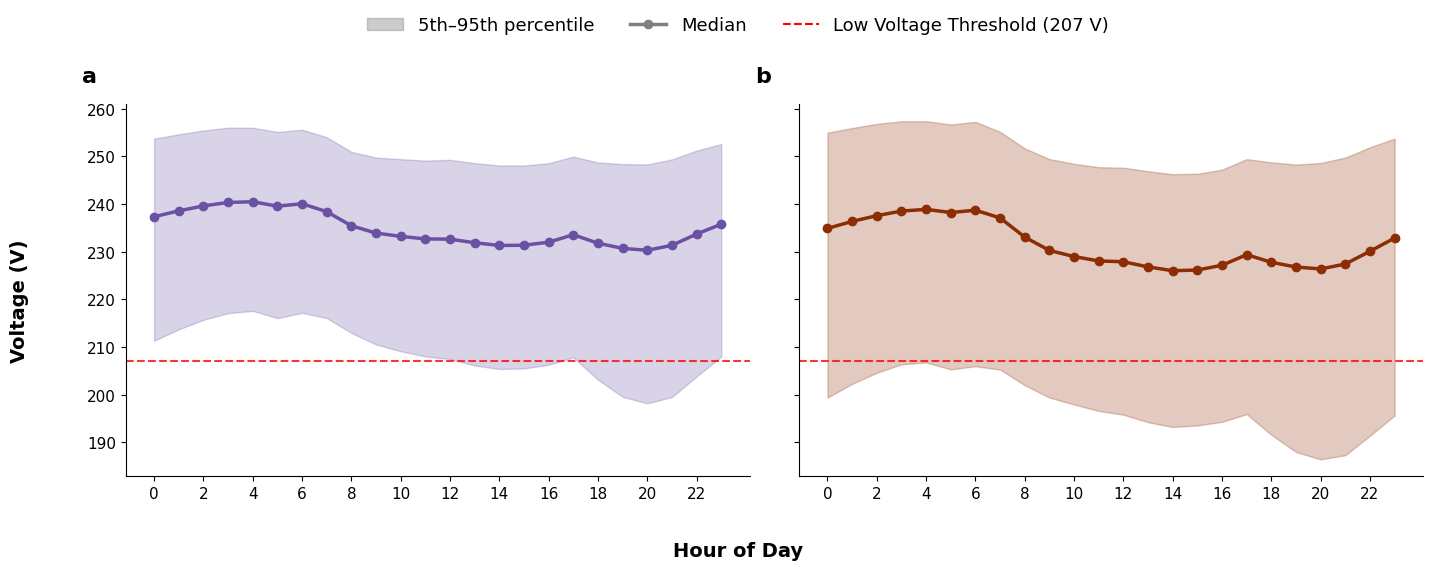

In [41]:
cesi_hourly_summary = plot_voltage_by_hour_of_day_by_cesi(
    combined_hourly_voltage_df,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    cesi_order=['Low', 'High'],
    figsize=(14, 5), 
    xtick_hours=[0,2,4,6,8,10,12,14,16,18,20,22],       
    # save_path='hour_of_day_by_cesi.png'
)

### Hour of day plots (`by month`)  

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_monthly_hour_of_day_profiles(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    months=None,
    figsize=(14, 10),
    ncols=3,
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,
    sharey=True,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    cesi_colors = {
        'Low': {'line': '#6a51a3', 'band': '#bcbddc'},
        'Medium': {'line': '#238b45', 'band': '#a1d99b'},
        'High': {'line': '#8c2d04', 'band': '#fdbb84'}
    }

    if line_color is None:
        line_color = cesi_colors.get(cesi_level, {}).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(cesi_level, {}).get('band', 'gray')

    plot_df['hour'] = plot_df['time'].dt.hour
    plot_df['month'] = plot_df['time'].dt.month
    plot_df['month_name'] = plot_df['time'].dt.month_name().str[:3]

    if months is not None:
        plot_df = plot_df[plot_df['month'].isin(months)]

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    grouped = (
        plot_df
        .groupby(['month', 'month_name', 'hour'])['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
    )

    month_order = [
        'Jan', 'Feb', 'Mar', 'Apr',
        'May', 'Jun', 'Jul', 'Aug',
        'Sep', 'Oct', 'Nov', 'Dec'
    ]

    grouped['month_name'] = pd.Categorical(
        grouped['month_name'],
        categories=month_order,
        ordered=True
    )

    grouped = grouped.sort_values(['month', 'hour'])

    unique_months = (
        grouped[['month', 'month_name']]
        .drop_duplicates()
        .sort_values('month')
    )

    n_months = len(unique_months)
    nrows = int(np.ceil(n_months / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, (_, row) in enumerate(unique_months.iterrows()):

        month_num = row['month']
        month_name = row['month_name']
        ax = axes[i]

        month_df = grouped[grouped['month'] == month_num]

        ax.fill_between(
            month_df['hour'],
            month_df['lower'],
            month_df['upper'],
            color=band_color,
            alpha=alpha_band
        )

        ax.plot(
            month_df['hour'],
            month_df['center_value'],
            color=line_color,
            linewidth=linewidth
        )

        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            month_name,
            fontsize=13,
            fontweight='bold'
        )

        ax.set_xticks(range(0, 24, 4))
        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title_prefix = f'{cesi_level} CESI | ' if cesi_level is not None else ''

    fig.suptitle(
        f'{title_prefix}Monthly Hour-of-Day Voltage Profiles',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    plt.tight_layout()
    plt.show()

    return grouped

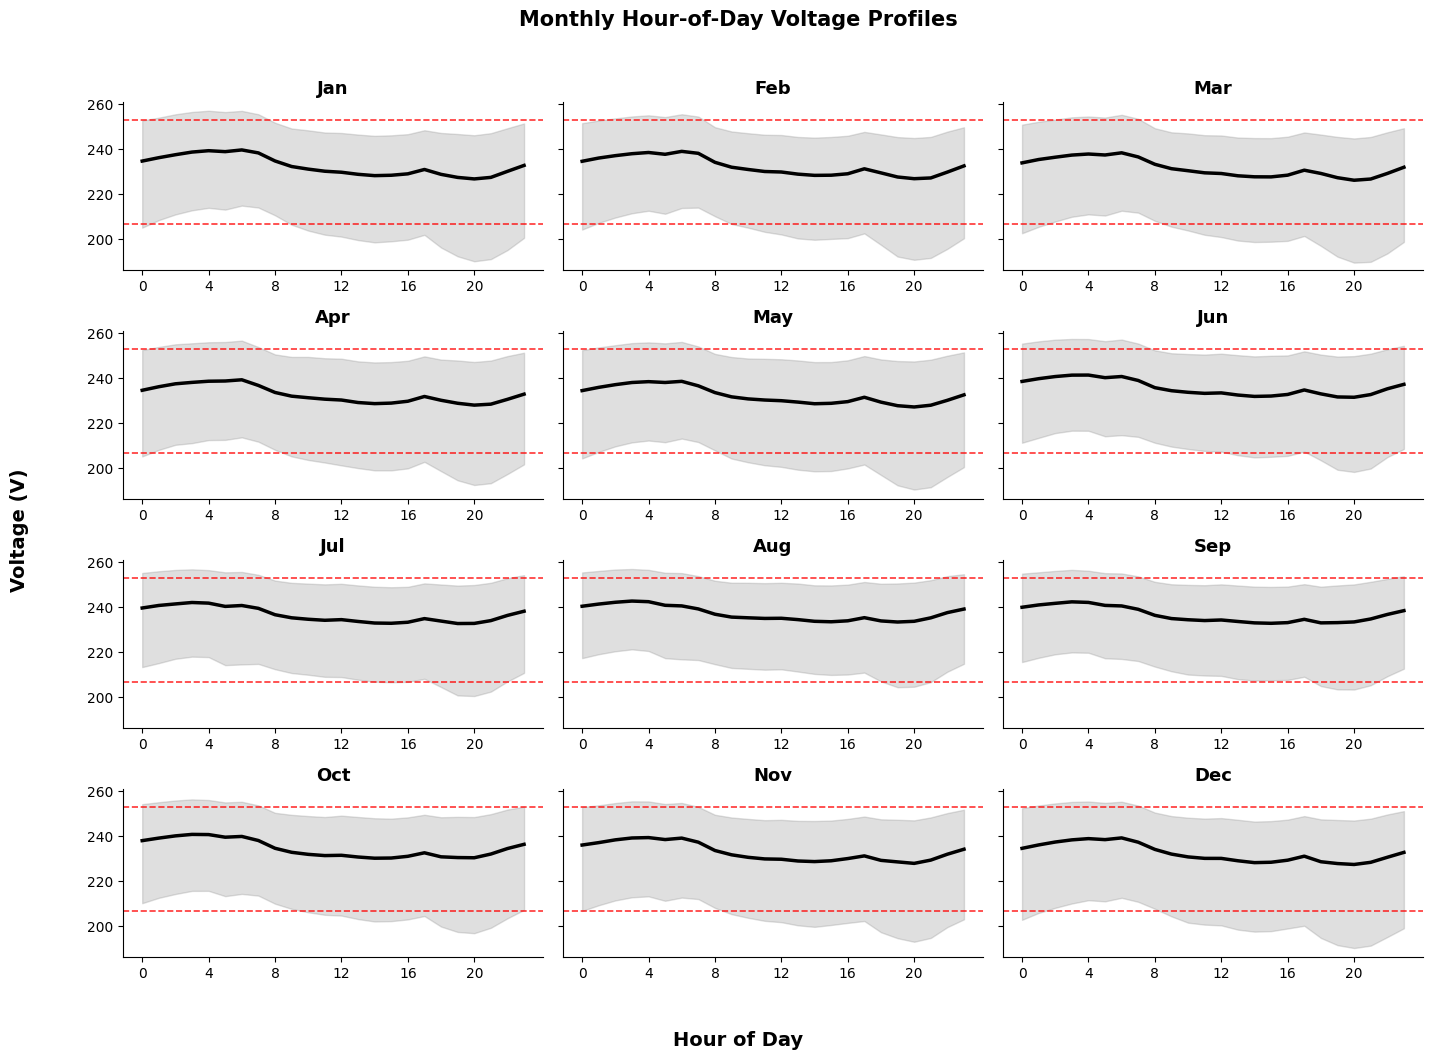

In [43]:
monthly_all = plot_monthly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level = None,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260)
)

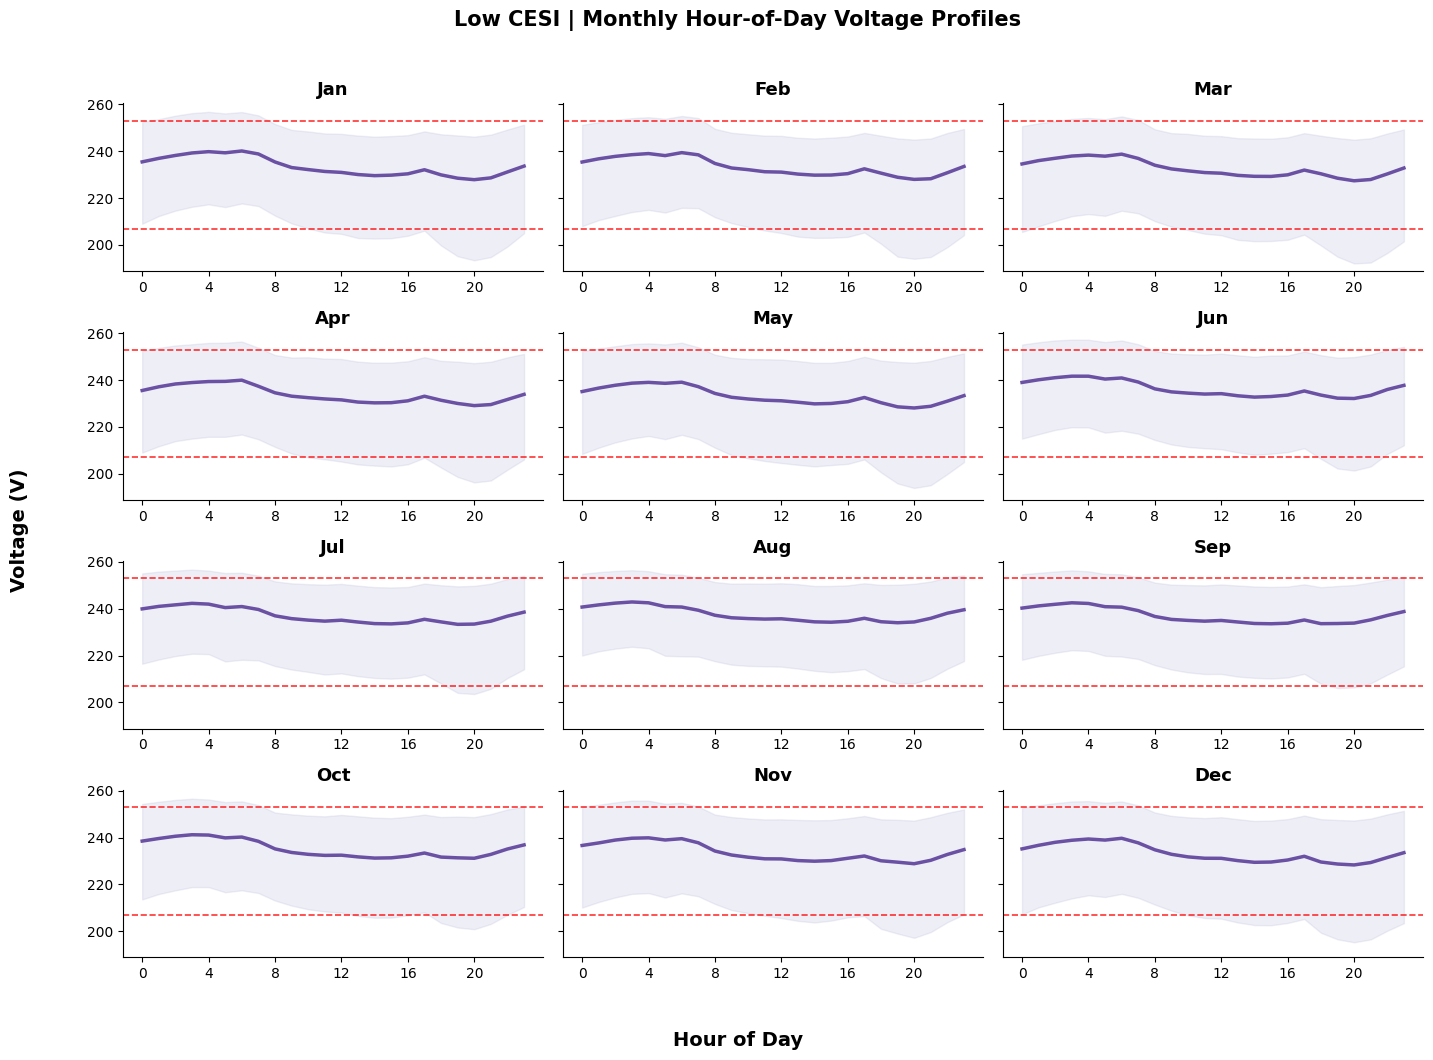

In [44]:
monthly_low = plot_monthly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level='Low',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260)
)

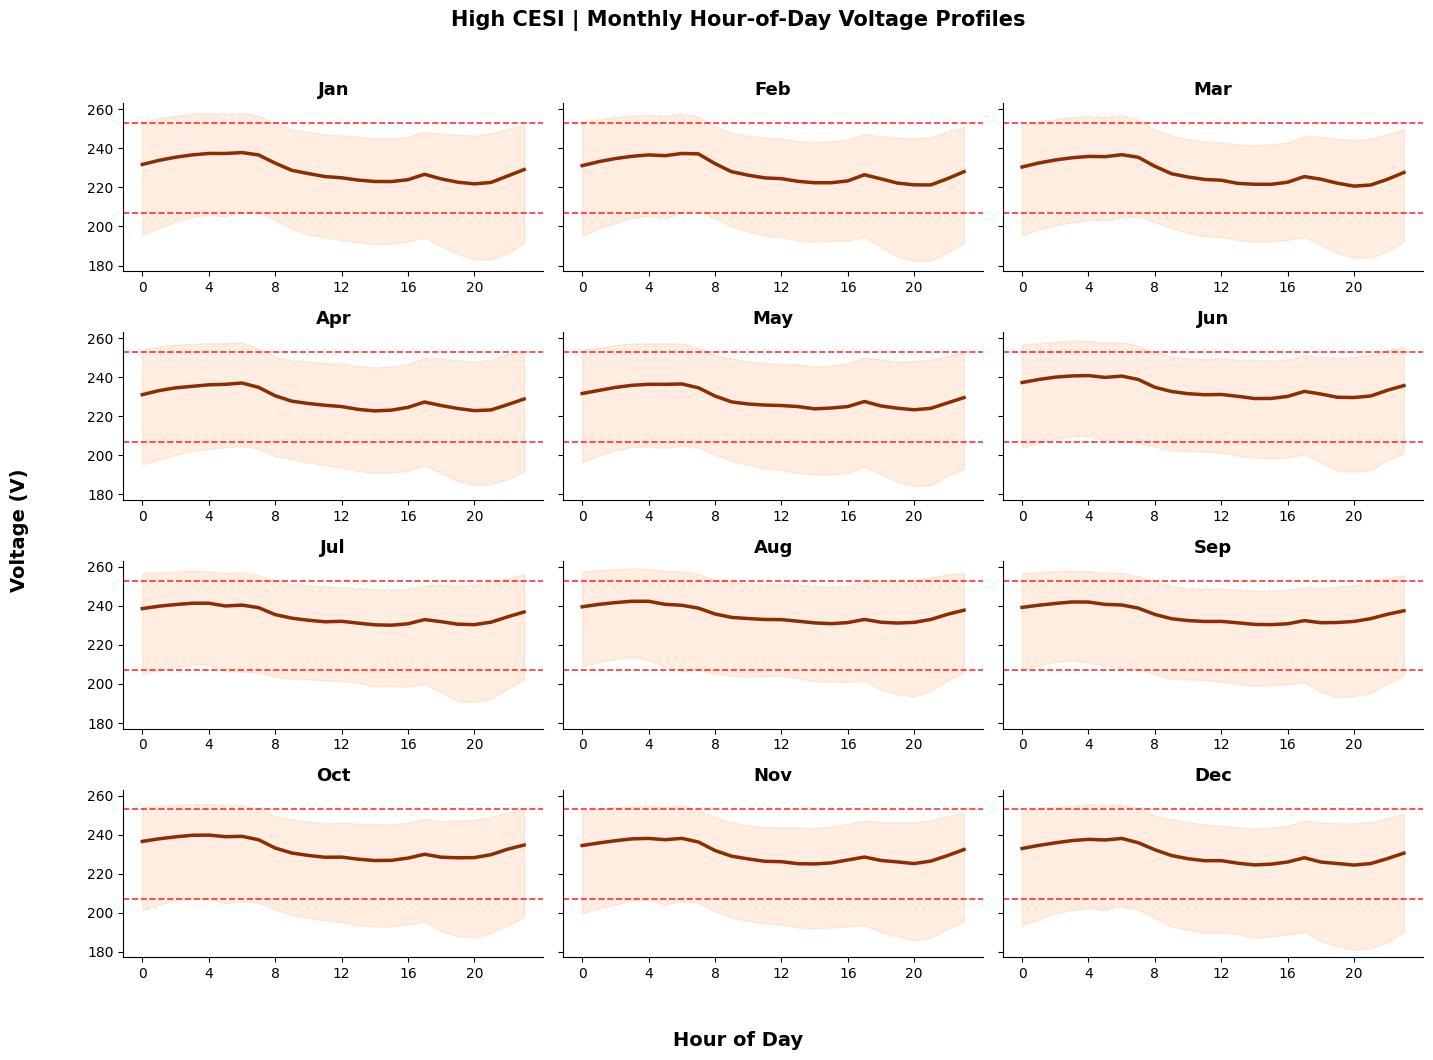

In [45]:
monthly_high = plot_monthly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level='High',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    # ylim=(180, 260)
)

### Hour of day plots (`by Quarter`)  

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quarterly_hour_of_day_profiles(
    df,
    site_ids=None,
    cesi_level=None,          # 'Low', 'High', or None
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(14, 8),
    ncols=2,
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Hour of Day',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,
    sharey=True,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    cesi_colors = {
        'Low': {'line': '#6a51a3', 'band': '#bcbddc'},
        'Medium': {'line': '#238b45', 'band': '#a1d99b'},
        'High': {'line': '#8c2d04', 'band': '#fdbb84'}
    }

    if line_color is None:
        line_color = cesi_colors.get(cesi_level, {}).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(cesi_level, {}).get('band', 'gray')

    plot_df['hour'] = plot_df['time'].dt.hour
    plot_df['quarter'] = plot_df['time'].dt.quarter
    plot_df['quarter_label'] = 'Q' + plot_df['quarter'].astype(str)

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    grouped = (
        plot_df
        .groupby(['quarter', 'quarter_label', 'hour'])['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values(['quarter', 'hour'])
    )

    unique_quarters = (
        grouped[['quarter', 'quarter_label']]
        .drop_duplicates()
        .sort_values('quarter')
    )

    n_quarters = len(unique_quarters)
    nrows = int(np.ceil(n_quarters / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, (_, row) in enumerate(unique_quarters.iterrows()):

        quarter_num = row['quarter']
        quarter_label = row['quarter_label']

        ax = axes[i]

        quarter_df = grouped[grouped['quarter'] == quarter_num]

        ax.fill_between(
            quarter_df['hour'],
            quarter_df['lower'],
            quarter_df['upper'],
            color=band_color,
            alpha=alpha_band
        )

        ax.plot(
            quarter_df['hour'],
            quarter_df['center_value'],
            color=line_color,
            linewidth=linewidth
        )

        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            quarter_label,
            fontsize=14,
            fontweight='bold'
        )

        ax.set_xticks(range(0, 24, 4))

        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title_prefix = f'{cesi_level} CESI | ' if cesi_level is not None else ''

    fig.suptitle(
        f'{title_prefix}Quarterly Hour-of-Day Voltage Profiles',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    plt.tight_layout()
    plt.show()

    return grouped

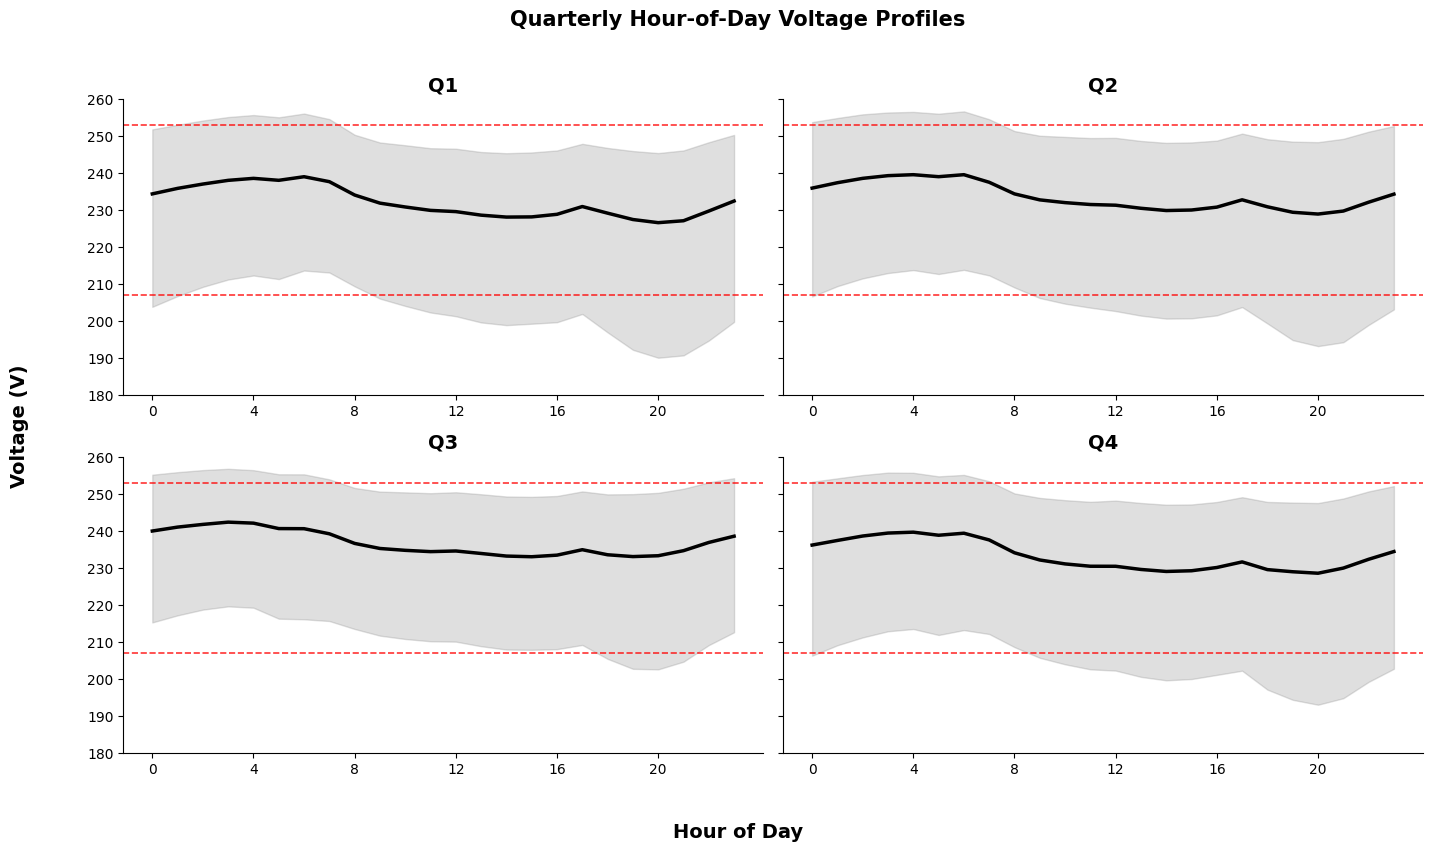

In [47]:
quarterly_all = plot_quarterly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level = None,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    ylim=(180, 260)
)

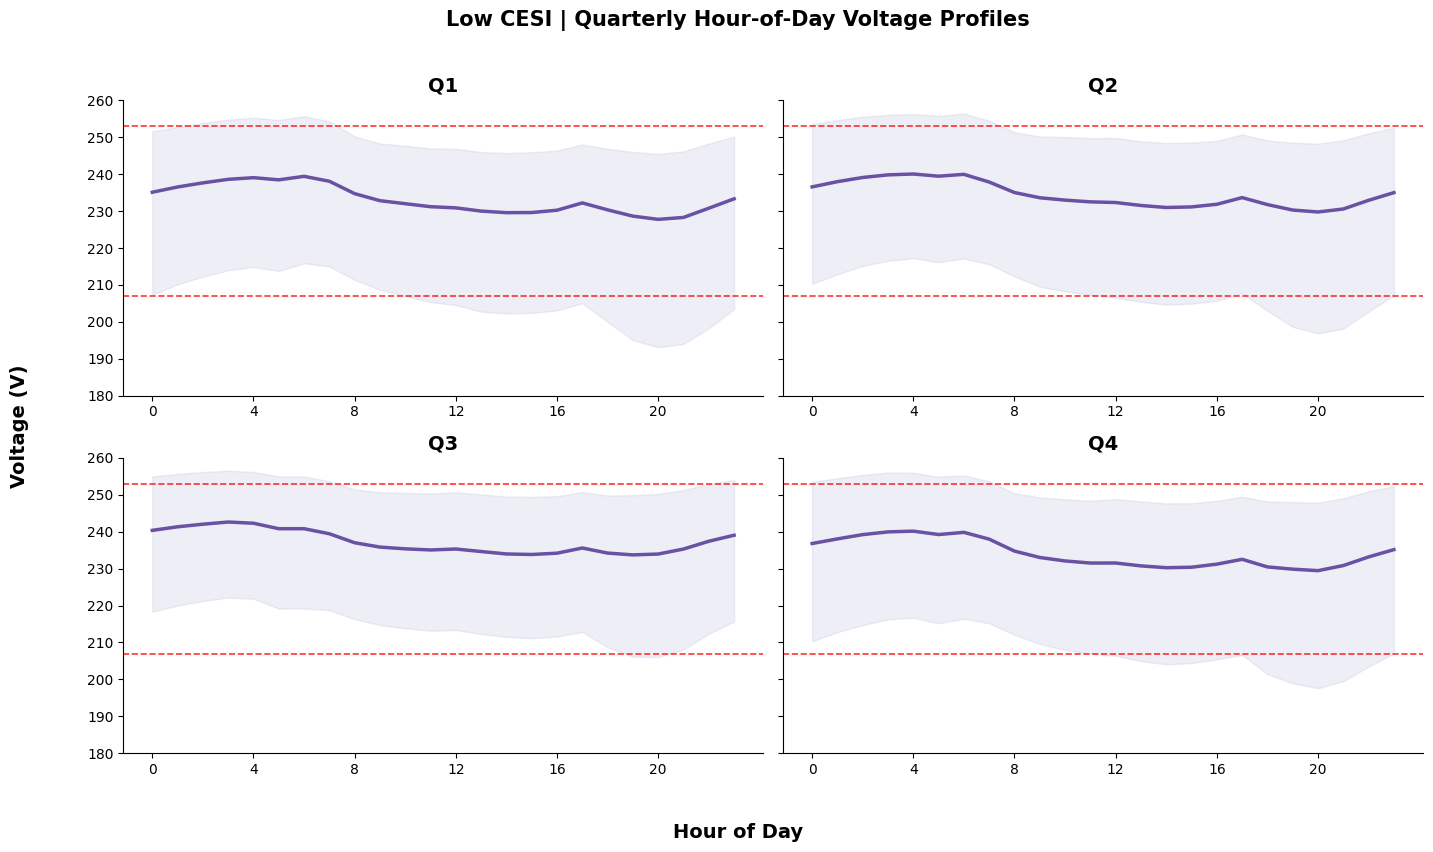

In [48]:
quarterly_low = plot_quarterly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level='Low',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    ylim=(180, 260)
)

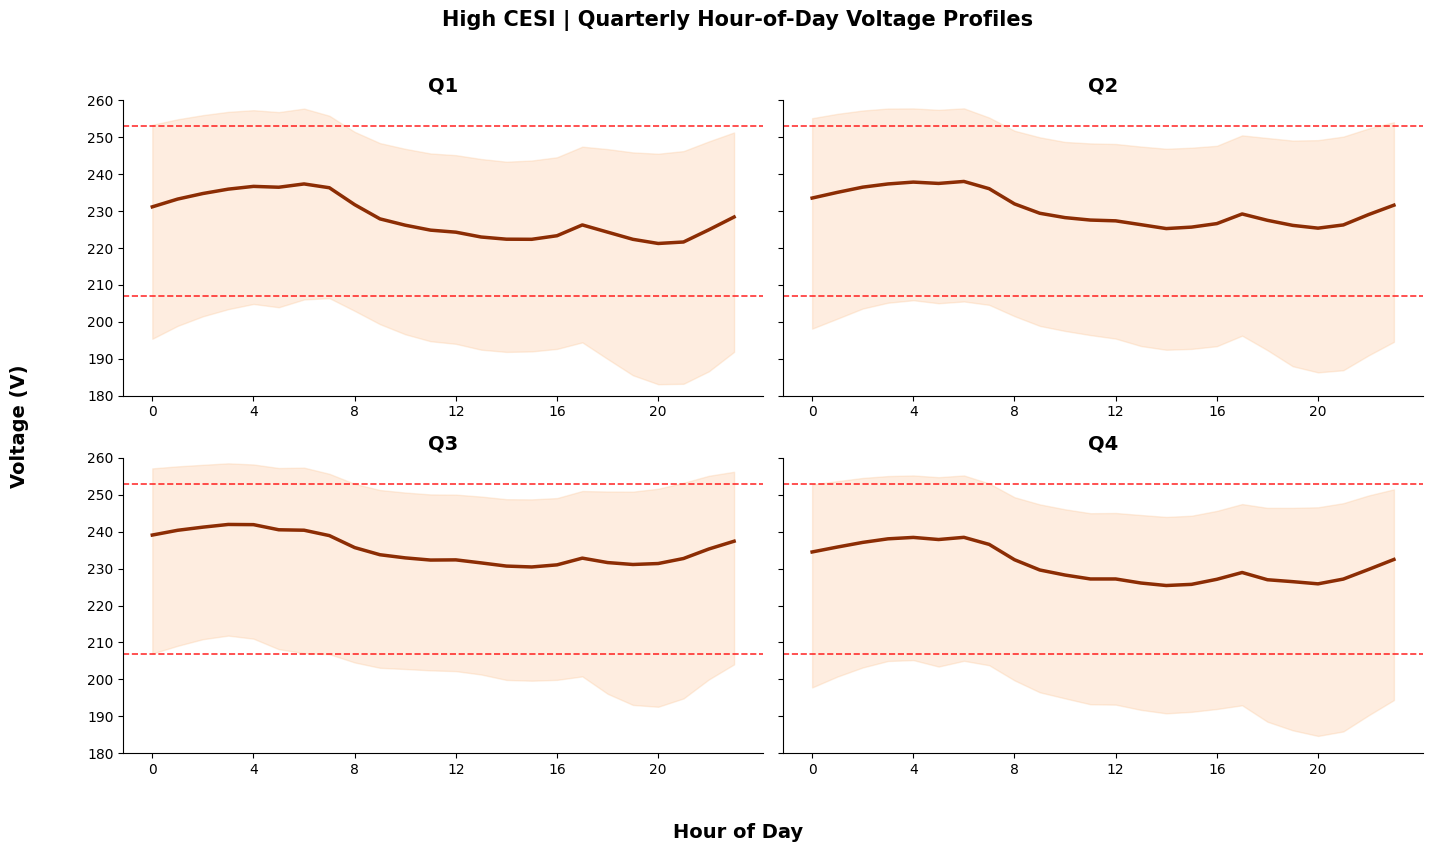

In [49]:
quarterly_high = plot_quarterly_hour_of_day_profiles(
    combined_hourly_voltage_df,
    cesi_level='High',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    ylim=(180, 260)
)

### Plain hourly - `by Quarter` 

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quarterly_elapsed_hour_profiles(
    df,
    site_ids=None,
    cesi_level=None,
    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,
    figsize=(14, 8),
    ncols=2,
    linewidth=2.5,
    alpha_band=0.25,
    line_color=None,
    band_color=None,
    ylabel='Voltage (V)',
    xlabel='Elapsed Hour in Quarter',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,
    sharey=True,
    ylim=None
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', 'voltage'])

    cesi_colors = {
        'Low': {'line': '#6a51a3', 'band': '#bcbddc'},
        'Medium': {'line': '#238b45', 'band': '#a1d99b'},
        'High': {'line': '#8c2d04', 'band': '#fdbb84'}
    }

    if line_color is None:
        line_color = cesi_colors.get(cesi_level, {}).get('line', 'black')

    if band_color is None:
        band_color = cesi_colors.get(cesi_level, {}).get('band', 'gray')

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    # -------------------------
    # Quarter + elapsed hour
    # -------------------------
    plot_df['quarter'] = plot_df['time'].dt.quarter
    plot_df['quarter_label'] = 'Q' + plot_df['quarter'].astype(str)

    plot_df['quarter_start'] = (
        plot_df['time']
        .dt.to_period('Q')
        .dt.start_time
    )

    plot_df['elapsed_hour_in_quarter'] = (
        (plot_df['time'] - plot_df['quarter_start'])
        .dt.total_seconds()
        / 3600
    ).astype(int)

    # -------------------------
    # Aggregate by quarter and elapsed hour
    # Pools 2022 + 2023 together
    # -------------------------
    grouped = (
        plot_df
        .groupby(
            ['quarter', 'quarter_label', 'elapsed_hour_in_quarter']
        )['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values(['quarter', 'elapsed_hour_in_quarter'])
    )

    unique_quarters = (
        grouped[['quarter', 'quarter_label']]
        .drop_duplicates()
        .sort_values('quarter')
    )

    n_quarters = len(unique_quarters)
    nrows = int(np.ceil(n_quarters / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    for i, (_, row) in enumerate(unique_quarters.iterrows()):

        quarter_num = row['quarter']
        quarter_label = row['quarter_label']

        ax = axes[i]

        quarter_df = grouped[
            grouped['quarter'] == quarter_num
        ]

        ax.fill_between(
            quarter_df['elapsed_hour_in_quarter'],
            quarter_df['lower'],
            quarter_df['upper'],
            color=band_color,
            alpha=alpha_band
        )

        ax.plot(
            quarter_df['elapsed_hour_in_quarter'],
            quarter_df['center_value'],
            color=line_color,
            linewidth=linewidth
        )

        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            quarter_label,
            fontsize=14,
            fontweight='bold'
        )

        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)

        sns.despine(ax=ax)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    title_prefix = f'{cesi_level} CESI | ' if cesi_level is not None else ''

    fig.suptitle(
        f'{title_prefix}Quarterly Voltage Profiles',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02
    )

    plt.tight_layout()
    plt.show()

    return grouped

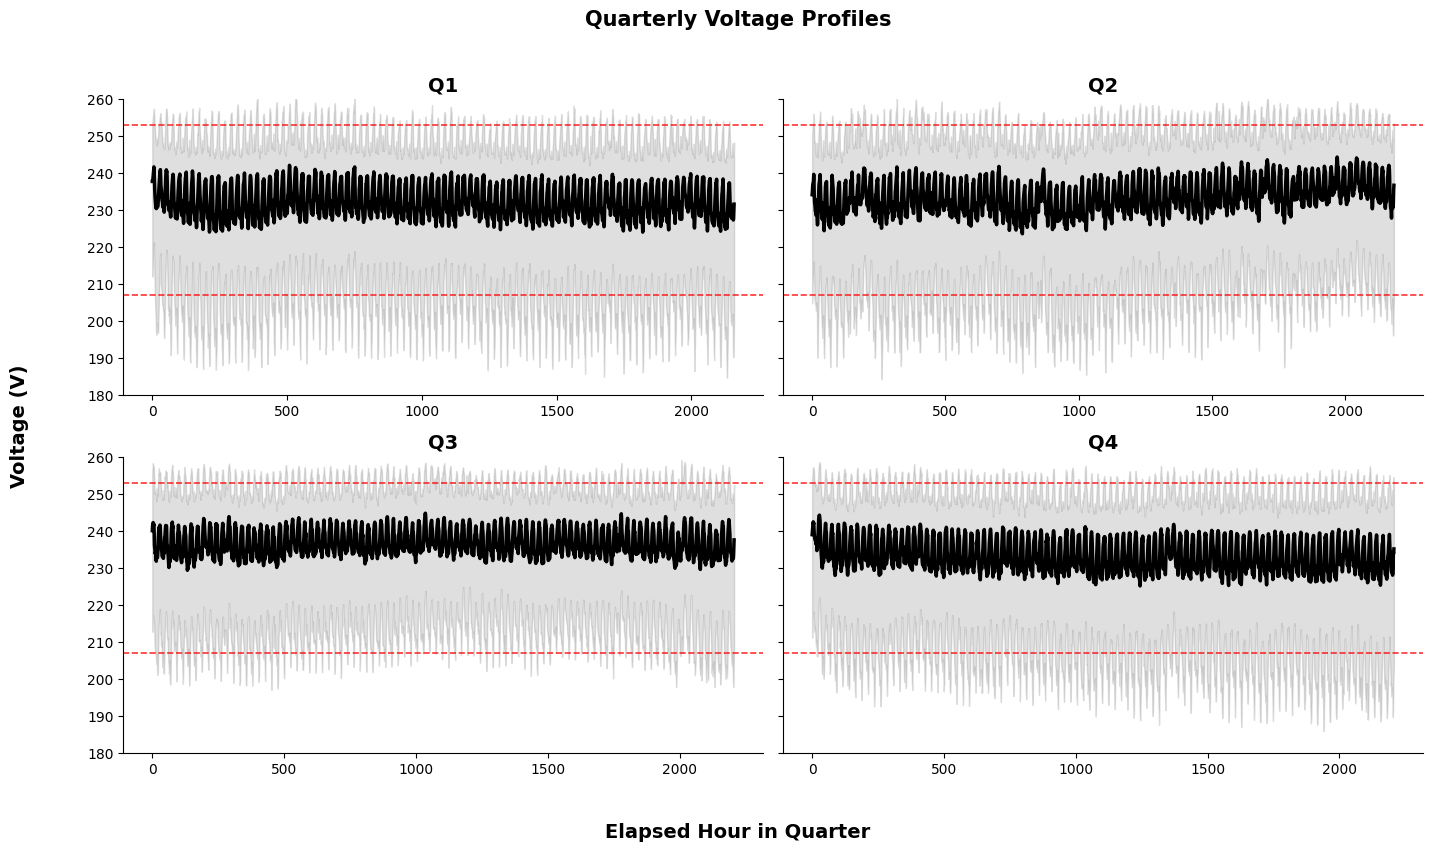

In [51]:
quarter_elapsed_all = plot_quarterly_elapsed_hour_profiles(
    combined_hourly_voltage_df,
    cesi_level = None,
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    ylim=(180, 260)
)